In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
from quimb.utils import progbar as Progbar
from mpi4py import MPI
import pickle
pwd = os.getcwd()

# torch
from torch.nn.parameter import Parameter
import torch
import torch.nn as nn
torch.autograd.set_detect_anomaly(False)

# quimb
import quimb as qu
import quimb.tensor as qtn
import autoray as ar
from autoray import do

from vmc_torch.experiment.tn_model import fTNModel, fTNModel_reuse
from vmc_torch.experiment.tn_model import fTN_Transformer_Model, fTN_Transformer_Proj_Model, fTN_Transformer_Proj_lazy_Model
from vmc_torch.experiment.tn_model import fTN_backflow_Model,fTN_backflow_attn_Model
from vmc_torch.experiment.tn_model import init_weights_xavier, init_weights_kaiming, init_weights_to_zero
from vmc_torch.sampler import MetropolisExchangeSamplerSpinful
from vmc_torch.variational_state import Variational_State
from vmc_torch.optimizer import SGD, SR
from vmc_torch.VMC import VMC
from vmc_torch.hamiltonian import spinful_Fermi_Hubbard_square_lattice
from vmc_torch.torch_utils import SVD,QR

# Register safe SVD and QR functions to torch
ar.register_function('torch','linalg.svd',SVD.apply)
ar.register_function('torch','linalg.qr',QR.apply)

from vmc_torch.global_var import DEBUG
from vmc_torch.utils import closest_divisible


COMM = MPI.COMM_WORLD
SIZE = COMM.Get_size()
RANK = COMM.Get_rank()

# Hamiltonian parameters
Lx = int(8)
Ly = int(8)
symmetry = 'Z2'
t = 1.0
U = 8.0
N_f = int(Lx*Ly)
n_fermions_per_spin = (N_f//2, N_f//2)
H = spinful_Fermi_Hubbard_square_lattice(Lx, Ly, t, U, N_f, pbc=False, n_fermions_per_spin=n_fermions_per_spin)
graph = H.graph
# TN parameters
D = 4
chi = -1
dtype=torch.float64

# Load PEPS
nersc = True
if nersc:
    skeleton = pickle.load(open(pwd+f"/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_skeleton_nersc.pkl", "rb"))
    peps_params = pickle.load(open(pwd+f"/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_su_params_nersc.pkl", "rb"))
else:
    skeleton = pickle.load(open(f'./{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_skeleton.pkl', "rb"))
    peps_params = pickle.load(open(f'./{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_su_params.pkl', "rb"))
peps = qtn.unpack(peps_params, skeleton)
for ts in peps.tensors:
    ts.data.phase_sync(inplace=True)
## 2. Scale the tensor elements
scale = 1.0
peps.apply_to_arrays(lambda x: torch.tensor(scale*x, dtype=dtype))
## 3. Set the exponent to 0.0
peps.exponent = 0.0

# VMC sample size
N_samples = int(10)
N_samples = closest_divisible(N_samples, SIZE)
if (N_samples/SIZE)%2 != 0:
    N_samples += SIZE

model = fTNModel(peps, max_bond=chi)
model.apply(lambda x: init_weights_to_zero(x, std=1e-2))

model_names = {
    fTNModel: 'fTN',
    fTN_backflow_Model: 'fTN_backflow',
    fTN_backflow_attn_Model: 'fTN_backflow_attn',
}
model_name = model_names.get(type(model), 'UnknownModel')

# Load PEPS
nersc = False
if nersc:
    skeleton = pickle.load(open(pwd+f"/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_skeleton_nersc.pkl", "rb"))
    peps_params = pickle.load(open(pwd+f"/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_su_params_nersc.pkl", "rb"))
else:
    skeleton = pickle.load(open(f'./{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_skeleton.pkl', "rb"))
    peps_params = pickle.load(open(f'./{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/peps_su_params.pkl', "rb"))
new_peps = qtn.unpack(peps_params, skeleton)
for ts in new_peps.tensors:
    ts.data.phase_sync(inplace=True)
## 2. Scale the tensor elements
scale = 1.0
new_peps.apply_to_arrays(lambda x: torch.tensor(scale*x, dtype=dtype))
## 3. Set the exponent to 0.0
new_peps.exponent = 0.0

model1 = fTNModel(new_peps, max_bond=chi)

/home/sijingdu/TNVMC/VMC_code/mpsds/mpsds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
current_config = torch.tensor([1,2,1,2,1,2,1,2,
                            2,1,2,1,2,1,2,1,
                            1,2,1,2,1,2,1,2,
                            2,1,2,1,2,1,2,1,
                            1,2,1,2,1,2,1,2,
                            2,1,2,1,2,1,2,1,
                            1,2,1,2,1,2,1,2,
                            2,1,2,1,2,1,2,1])
model.clear_grad(), model1.clear_grad()
model(current_config).backward(), model1(current_config).backward()

F=8.23 C=9.01 S=20.00 P=21.01: 100%|██████████| 10/10 [00:00<00:00, 19.64it/s] 


(None, None)

In [3]:
model(current_config), model1(current_config)

(tensor([3.4753e-25], dtype=torch.float64, grad_fn=<StackBackward0>),
 tensor([-6.9992e-25], dtype=torch.float64, grad_fn=<StackBackward0>))

In [4]:
model.params_grad_to_vec().max(), model1.params_grad_to_vec().max()

(tensor(6.6457e-25, dtype=torch.float64),
 tensor(1.3018e-24, dtype=torch.float64))

In [5]:
model.params_grad_to_vec().max()/model(current_config), model1.params_grad_to_vec().max()/model1(current_config)

(tensor([1.9123], dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor([-1.8599], dtype=torch.float64, grad_fn=<DivBackward0>))

In [38]:
import symmray as sr
edges = qtn.edges_2d_square(Lx, Ly, cyclic=False)
site_info = sr.utils.parse_edges_to_site_info(
    edges,
    D,
    phys_dim=4,
    site_ind_id="k{},{}",
    site_tag_id="I{},{}",
)
t = 1.0
U = 8.0
mu = 0.0

terms = {
    (sitea, siteb): sr.fermi_hubbard_local_array(
        t=t, U=U, mu=mu,
        symmetry=symmetry,
        coordinations=(
            site_info[sitea]['coordination'],
            site_info[siteb]['coordination'],
        ),
    ).fuse((0, 1), (2, 3))
    for (sitea, siteb) in peps.gen_bond_coos()
}
ham = qtn.LocalHam2D(Lx, Ly, terms)

new_peps_np = new_peps.copy()
new_peps_np.apply_to_arrays(lambda x: x.detach().numpy())
peps_np = qtn.unpack(peps_params, skeleton)
# peps_np.apply_to_arrays(lambda x: x.detach().numpy())
new_peps_np.compute_local_expectation_exact(ham.terms)/(Lx*Ly), peps_np.compute_local_expectation_exact(ham.terms)/(Lx*Ly)
# peps_np.to_dense().blocks[(4,0)]==new_peps_np.to_dense().blocks[(4,0)]

(np.float64(-0.1706061411832418), np.float64(-0.19562167616576284))

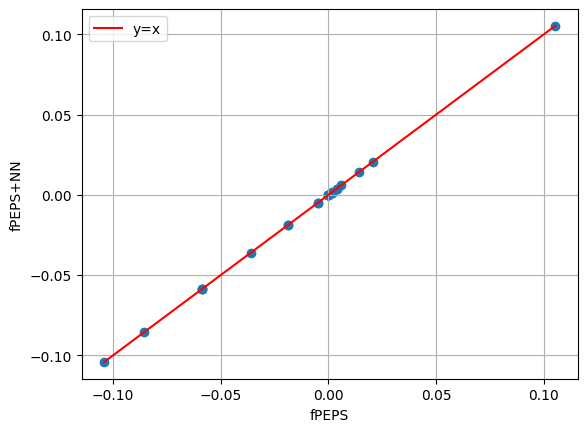

In [39]:
import matplotlib.pyplot as plt
import jax
seed = 42
np.random.seed(seed)
random_seed_list = np.random.randint(0, 2**32, size=25)

model1_list = []
model_list = []

for random_seed in random_seed_list:
    random_config = H.hilbert.random_state(jax.random.PRNGKey(random_seed))
    random_config = torch.tensor(random_config, dtype=int)
    model1_list.append(model1(random_config)[0].detach().numpy())
    model_list.append(model(random_config)[0].detach().numpy())

fig, ax = plt.subplots()
ax.scatter(model1_list, model_list)
# plot y=x as reference
x = np.linspace(min(model1_list+model_list), max(model1_list+model_list), 100)
ax.plot(x, x, color='red', label='y=x')
ax.set_xlabel('fPEPS')
ax.set_ylabel('fPEPS+NN')
ax.grid()
plt.legend()
plt.show()